In [1]:
pip install mysql-connector-python pandas seaborn matplotlib

In [2]:
import mysql.connector
import pandas as pd

# MySQL Connection Details
db_config = {
    "host": "127.0.0.1",  # e.g., "localhost"
    "user": "root",
    "password": "admin",
    "database": "amazon_sale"
}

In [3]:
# Establish Connection
conn = mysql.connector.connect(**db_config)

# Define Table Names
tables = ["amazon_sales_part_1", "amazon_sales_part_2", "amazon_sales_part_3", "amazon_sales_part_4"]

# Load Data into Pandas DataFrames and Merge
dfs = [pd.read_sql(f"SELECT * FROM {table}", conn) for table in tables]

# Close Connection
conn.close()

# Combine All Parts into a Single DataFrame
df= pd.concat(dfs, ignore_index=True)

# Display First Few Rows
print(df.head())

C:\Users\Admin\AppData\Local\Temp\ipykernel_11724\431173422.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs = [pd.read_sql(f"SELECT * FROM {table}", conn) for table in tables]


   index             Order_ID        Date                        Status  \
0      0  405-8078784-5731545  2022-04-30                     Cancelled   
1      1  171-9198151-1101146  2022-04-30  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  2022-04-30                       Shipped   
3      3  403-9615377-8133951  2022-04-30                     Cancelled   
4      4  407-1069790-7240320  2022-04-30                       Shipped   

  Fulfilment Sales_channel ship_service_level    Style              SKU  \
0   Merchant     Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant     Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon     Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant     Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon     Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... Qty Currency  Amount    ship_city   ship_state  \
0            SET  ...   0 

In [4]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df

,index,Order_ID,Date,Status,Fulfilment,Sales_channel,ship_service_level,Style,SKU,Category,...,Qty,Currency,Amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,B2B,month
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,SET,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,NO PROMO,FALSE,April
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,KURTA,...,1,INR,406.00,BANGALORE,KARNATAKA,560085,IN,AMAZON PLCC FREE-FINANCING UNIVERSAL MERCHANT ...,FALSE,April
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,KURTA,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,IN CORE FREE SHIPPING 2015/04/08 23-48-5-108,TRUE,April
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,WESTERN DRESS,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,NO PROMO,FALSE,April
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,TOP,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073,IN,NO PROMO,FALSE,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128964,128970,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,KURTA,...,1,INR,517.00,HYDERABAD,TELANGANA,500013,IN,NO PROMO,FALSE,May
128965,128971,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,SET,...,1,INR,999.00,GURUGRAM,HARYANA,122004,IN,IN CORE FREE SHIPPING 2015/04/08 23-48-5-108,FALSE,May
128966,128972,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,WESTERN DRESS,...,1,INR,690.00,HYDERABAD,TELANGANA,500049,IN,NO PROMO,FALSE,May
128967,128973,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,SET,...,1,INR,1199.00,HALOL,GUJARAT,389350,IN,IN CORE FREE SHIPPING 2015/04/08 23-48-5-108,FALSE,May


In [6]:

df.drop(columns=['index'], inplace=True, errors='ignore')
df


,Order_ID,Date,Status,Fulfilment,Sales_channel,ship_service_level,Style,SKU,Category,Size,...,Qty,Currency,Amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,B2B,month
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,SET,S,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,NO PROMO,FALSE,April
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,KURTA,3XL,...,1,INR,406.00,BANGALORE,KARNATAKA,560085,IN,AMAZON PLCC FREE-FINANCING UNIVERSAL MERCHANT ...,FALSE,April
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,KURTA,XL,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,IN CORE FREE SHIPPING 2015/04/08 23-48-5-108,TRUE,April
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,WESTERN DRESS,L,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,NO PROMO,FALSE,April
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,TOP,3XL,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073,IN,NO PROMO,FALSE,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128964,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,KURTA,XL,...,1,INR,517.00,HYDERABAD,TELANGANA,500013,IN,NO PROMO,FALSE,May
128965,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,SET,M,...,1,INR,999.00,GURUGRAM,HARYANA,122004,IN,IN CORE FREE SHIPPING 2015/04/08 23-48-5-108,FALSE,May
128966,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,WESTERN DRESS,XXL,...,1,INR,690.00,HYDERABAD,TELANGANA,500049,IN,NO PROMO,FALSE,May
128967,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,SET,XS,...,1,INR,1199.00,HALOL,GUJARAT,389350,IN,IN CORE FREE SHIPPING 2015/04/08 23-48-5-108,FALSE,May


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128969 entries, 0 to 128968
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order_ID            128969 non-null  object 
 1   Date                128969 non-null  object 
 2   Status              128969 non-null  object 
 3   Fulfilment          128969 non-null  object 
 4   Sales_channel       128969 non-null  object 
 5   ship_service_level  128969 non-null  object 
 6   Style               128969 non-null  object 
 7   SKU                 128969 non-null  object 
 8   Category            128969 non-null  object 
 9   Size                128969 non-null  object 
 10  ASIN                128969 non-null  object 
 11  Courier_Status      128969 non-null  object 
 12  Qty                 128969 non-null  int64  
 13  Currency            128969 non-null  object 
 14  Amount              128969 non-null  float64
 15  ship_city           128969 non-nul

In [8]:
df.isnull().sum()

Order_ID              0
Date                  0
Status                0
Fulfilment            0
Sales_channel         0
ship_service_level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier_Status        0
Qty                   0
Currency              0
Amount                0
ship_city             0
ship_state            0
ship_postal_code      0
ship_country          0
promotion_ids         0
B2B                   0
month                 0
dtype: int64

In [9]:
df.shape

(128969, 22)

In [10]:
df.describe(include='all')

,Order_ID,Date,Status,Fulfilment,Sales_channel,ship_service_level,Style,SKU,Category,Size,...,Qty,Currency,Amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,B2B,month
count,128969,128969,128969,128969,128969,128969,128969,128969,128969,128969,...,128969.00000,128969,128969.000000,128969,128969,128969.000000,128969,128969,128969,128969
unique,120378,91,13,2,2,2,1377,7195,9,11,...,NaN,1,NaN,7201,38,NaN,2,5788,2,4
top,403-4984515-8861958,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,SET,M,...,NaN,INR,NaN,BANGALORE,MAHARASHTRA,NaN,IN,NO PROMO,FALSE,April
freq,12,2083,77801,89692,128845,88609,4224,773,50281,22709,...,NaN,128969,NaN,13342,22259,NaN,128936,49150,128098,49065
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.90445,NaN,609.371580,NaN,NaN,463847.945638,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.31333,NaN,313.335444,NaN,NaN,191594.282060,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00000,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00000,NaN,413.000000,NaN,NaN,382421.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00000,NaN,583.000000,NaN,NaN,500033.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00000,NaN,771.000000,NaN,NaN,600024.000000,NaN,NaN,NaN,NaN


# **DATA ANALYSIS**

## 1) Which categories have sold most?

In [13]:
# Which categories have sold most?
df_q1 = df[['Amount', 'Qty']].groupby(df['Category']).sum()\
                                .sort_values('Amount', ascending=False)\
                                .reset_index()
df_q1

,Category,Amount,Qty
0,SET,39202022.03,45287
1,KURTA,21299013.70,45044
2,WESTERN DRESS,11216072.69,13943
3,TOP,5347792.30,9903
4,ETHNIC DRESS,791217.66,1053
5,BLOUSE,458408.18,863
6,BOTTOM,150667.98,398
7,SAREE,123933.76,152
8,DUPATTA,915.00,3


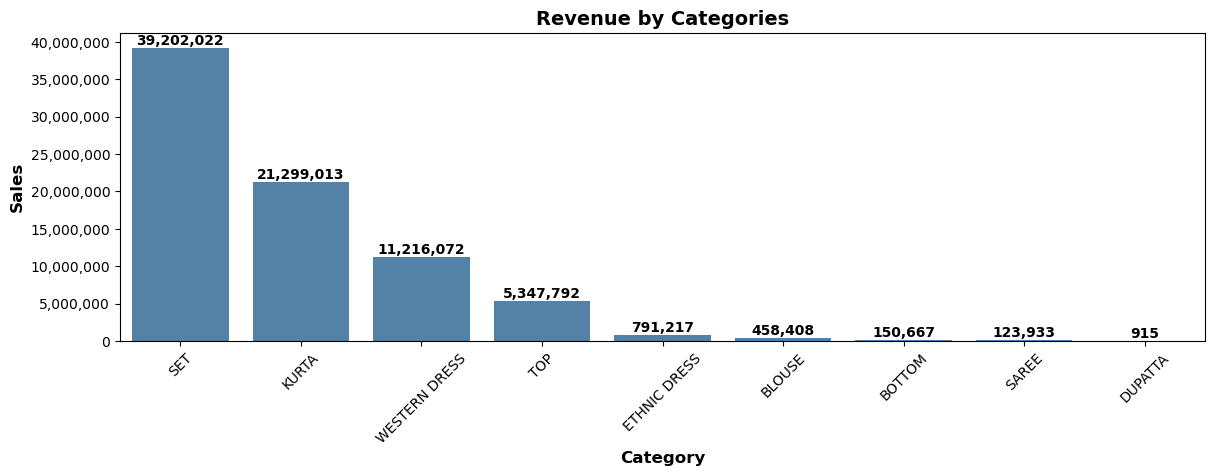

In [93]:
# Set figure size
plt.figure(figsize=(14, 4))

# Create bar plot
ax = sns.barplot(x="Category", y="Amount", data=df_q1, color='steelblue')

# Format y-axis labels for better readability (e.g., 1,000,000 instead of 1000000)
ax.get_yaxis().set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Add labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Set title and labels
plt.title("Revenue by Categories", fontsize=14, fontweight='bold')
plt.xlabel("Category", fontsize=12, fontweight='bold')
plt.ylabel("Sales", fontsize=12, fontweight='bold')

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Show the plot
plt.show()

## Inference: The top three categories that sold the most were SET(39,202,022), KURTA(21,299,013), and WESTERN DRESS(11,216,072).

# 2) Which are the 20 Best-Selling Products?

In [17]:
df_q2 = df.groupby(['Category', 'ASIN'])[['Qty','Amount']].sum()\
                                     .sort_values('Qty', ascending=False)\
                                     .head(20)\
                                     .reset_index()
df_q2

,Category,ASIN,Qty,Amount
0,WESTERN DRESS,B09SDXFFQ1,661,524581.77
1,WESTERN DRESS,B09SDY8DCT,561,454290.16
2,WESTERN DRESS,B09SDYQ3WG,503,407302.57
3,KURTA,B081WSCKPQ,485,194645.29
4,SET,B08XNJG8B1,467,526536.20
5,SET,B08XNJ19QH,421,479937.14
6,WESTERN DRESS,B09SDXRYBG,415,332155.24
7,KURTA,B081WX4G4Q,399,169808.87
8,WESTERN DRESS,B09SDY9SQ6,386,303616.70
9,SET,B08XQBF1G4,373,284058.96


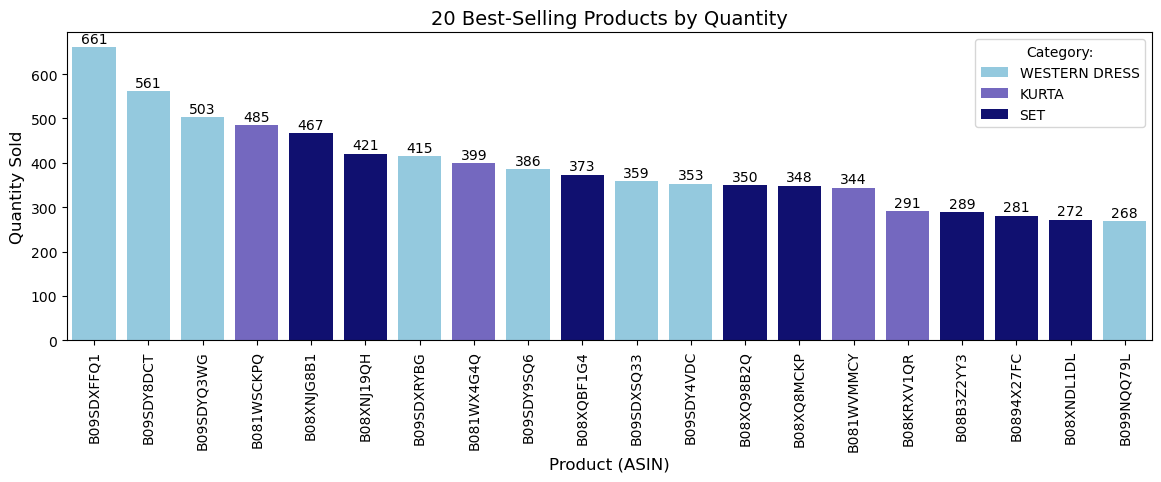

In [91]:
# Set figure size
plt.figure(figsize=(14, 4))

# Create bar plot using Seaborn
sns.barplot(
    x="ASIN",  # ASIN represents the product identifier
    y="Qty",   # Qty represents the quantity sold
    hue="Category",  # Category to differentiate product types
    data=df_q2,
    palette=["skyblue", "slateblue", "navy"]
)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=90)

# Set labels and title
plt.xlabel("Product (ASIN)", fontsize=12)
plt.ylabel("Quantity Sold", fontsize=12)
plt.title("20 Best-Selling Products by Quantity", fontsize=14)

# Display values on bars
for index, row in enumerate(df_q2.itertuples()):
    plt.text(index, row.Qty + 10, str(row.Qty), ha='center', fontsize=10)

# Show the legend
plt.legend(title="Category:")

# Show the plot
plt.show()


#Inference: It was verified that the 20 Best-Selling Products by quantity belongs to the categories Western Dress, Kurta and Set.

# 3) Which are the 20 Best-Selling Products by Revenue?

In [21]:
df_q3 = df.groupby(['Category', 'ASIN'])[['Amount', 'Qty']].sum()\
                                     .sort_values('Amount', ascending=False)\
                                     .head(20)\
                                     .reset_index()
df_q3

,Category,ASIN,Amount,Qty
0,SET,B08XNJG8B1,526536.20,467
1,WESTERN DRESS,B09SDXFFQ1,524581.77,661
2,SET,B08XNJ19QH,479937.14,421
3,WESTERN DRESS,B09SDY8DCT,454290.16,561
4,WESTERN DRESS,B09SDYQ3WG,407302.57,503
5,WESTERN DRESS,B09SDXRYBG,332155.24,415
6,SET,B08XNDL1DL,305616.95,272
7,WESTERN DRESS,B09SDY9SQ6,303616.70,386
8,SET,B08XQBF1G4,284058.96,373
9,WESTERN DRESS,B09SDY4VDC,276375.80,353


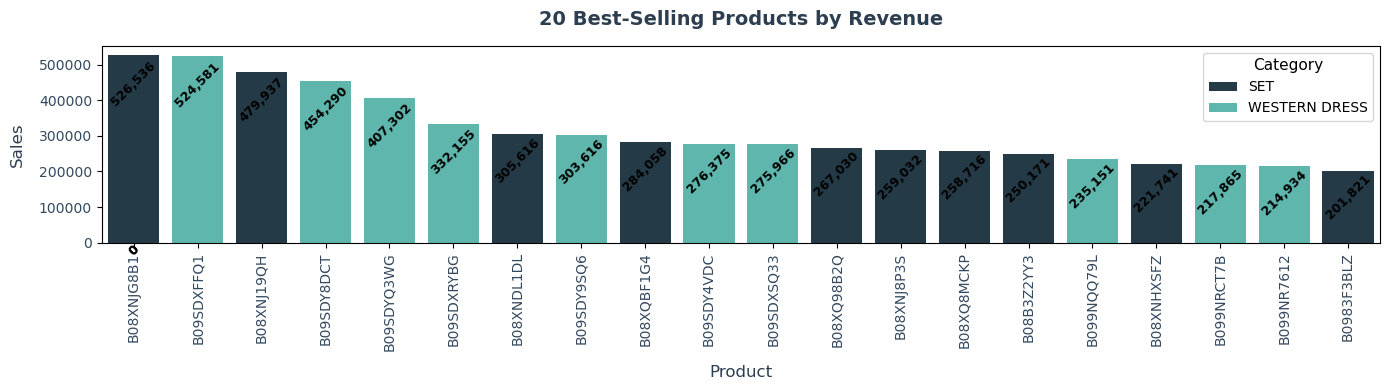

In [95]:
# Set figure size
plt.figure(figsize=(14, 4))

# Define the same colors
colors = ["#1F3B4D", "#50C5B7"]  # Dark blue and light blue

# Create a bar plot with the same color palette
ax = sns.barplot(x="ASIN", y="Amount", hue="Category", data=df_q3, palette=colors)

# Add data labels inside bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',  # Format number with commas
                (p.get_x() + p.get_width() / 2., p.get_height() * 0.98),  # Position inside the bar
                ha='center', va='top', fontsize=9, rotation=45, color='black', fontweight='bold')

# Set title and labels
plt.title("20 Best-Selling Products by Revenue", fontsize=14, fontweight='bold', pad=15, color="#2C3E50")
plt.xlabel("Product", fontsize=12, labelpad=10, color="#2C3E50")
plt.ylabel("Sales", fontsize=12, labelpad=10, color="#2C3E50")

# Rotate x-axis labels for better visibility
plt.xticks(rotation=90, fontsize=10, color="#34495E")
plt.yticks(fontsize=10, color="#34495E")

# Adjust legend
plt.legend(title="Category", fontsize=10, title_fontsize=11, loc="upper right")

# Remove gridlines
ax.grid(False)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()



##Inference : On the other hand, the 20 Best-Selling Products by revenue belongs only to the categories Western Dress and Set.

# 4) Which are the 15 cities that made the most orders?

In [103]:
df_q4 = df.groupby(['ship_state','ship_city'])[['Order_ID']].count()\
                                    .sort_values('Order_ID', ascending=False)\
                                    .head(15)\
                                    .reset_index()
df_q4

,ship_state,ship_city,Order_ID
0,KARNATAKA,BANGALORE,13342
1,TELANGANA,HYDERABAD,9092
2,MAHARASHTRA,MUMBAI,7122
3,DELHI,NEW DELHI,6753
4,TAMIL NADU,CHENNAI,6284
5,MAHARASHTRA,PUNE,4616
6,WEST BENGAL,KOLKATA,2844
7,HARYANA,GURUGRAM,1954
8,MAHARASHTRA,THANE,1877
9,UTTAR PRADESH,LUCKNOW,1627


C:\Users\Admin\AppData\Local\Temp\ipykernel_11724\1703863542.py:13: UserWarning: The palette list has more values (20) than needed (10), which may not be intended.
  ax = sns.barplot(


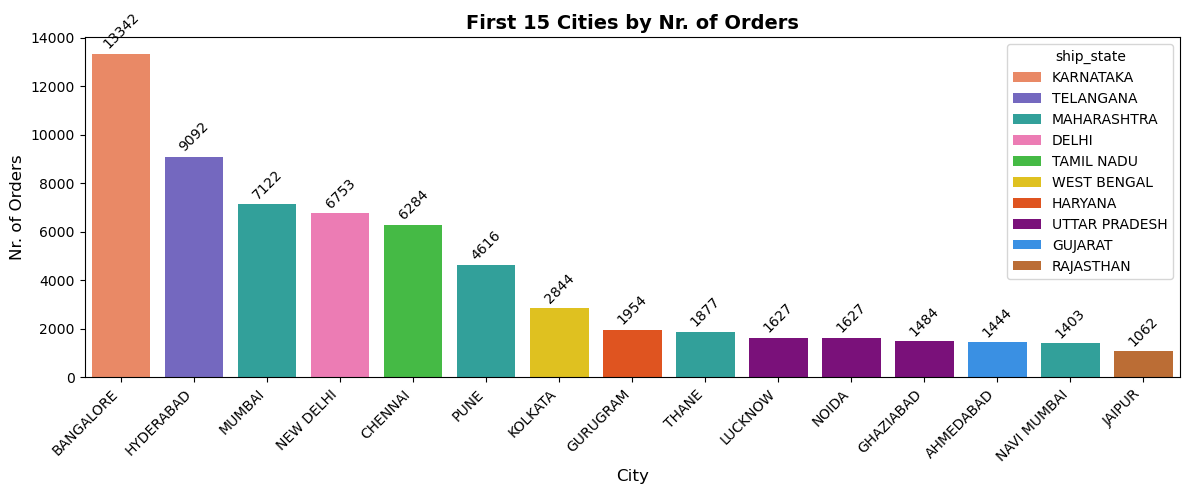

In [105]:


# Set figure size
plt.figure(figsize=(12, 5))

# Define a new color palette
new_colors = [
    "#FF7F50", "#6A5ACD", "#20B2AA", "#FF69B4", "#32CD32", "#FFD700",
    "#FF4500", "#8B008B", "#1E90FF", "#D2691E", "#DC143C", "#00BFFF",
    "#FF6347", "#3CB371", "#ADFF2F", "#B22222", "#7B68EE", "#8FBC8F",
    "#EE82EE", "#A52A2A"
]

# Create bar plot
ax = sns.barplot(
    x="ship_city", y="Order_ID", hue="ship_state", data=df_q4, palette=new_colors
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add title and labels
plt.title("First 15 Cities by Nr. of Orders", fontsize=14, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Nr. of Orders", fontsize=12)



# Adjust layout
plt.tight_layout()

# Annotate each bar with its value (avoiding "0" issue)
for p in ax.patches:
    value = int(p.get_height())
    if value > 0:
        ax.annotate(
            f"{value}",
            (p.get_x() + p.get_width() / 2., p.get_height() + 100),
            ha='center',
            va='bottom',
            fontsize=10,
            rotation=45
        )


# Show plot
plt.show()


##Inference: A ranking of the 20 cities with the most orders was created, and each region was assigned a color in the chart. Bangalore is the city with the highest number of orders.

# 5) Which are the 20 cities that more income generate?

In [29]:
df_q5 = df.groupby(['ship_state','ship_city'])[['Amount','Qty']].sum()\
                                    .sort_values('Amount', ascending=False)\
                                     .head(20)\
                                    .reset_index()
df_q5

,ship_state,ship_city,Amount,Qty
0,KARNATAKA,BANGALORE,8137402.15,12390
1,TELANGANA,HYDERABAD,5579520.35,8252
2,MAHARASHTRA,MUMBAI,4293210.16,6576
3,DELHI,NEW DELHI,4205548.28,6129
4,TAMIL NADU,CHENNAI,3606917.94,5756
5,MAHARASHTRA,PUNE,2794036.79,4236
6,WEST BENGAL,KOLKATA,1682046.99,2586
7,HARYANA,GURUGRAM,1280854.78,1815
8,MAHARASHTRA,THANE,1111506.35,1703
9,UTTAR PRADESH,LUCKNOW,1049983.10,1441


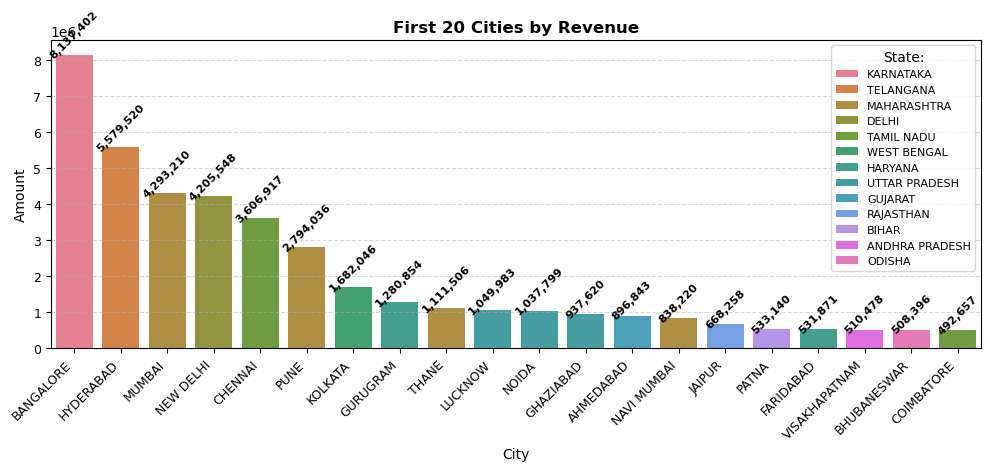

In [111]:
# Set figure size
plt.figure(figsize=(12, 4))

# Create the bar plot
ax = sns.barplot(data=df_q5, x="ship_city", y="Amount", hue="ship_state", dodge=False)

# Add data labels above bars (Fix Bangalore issue)
for p in ax.patches:
    value = int(p.get_height())
    if value > 0:  # Only display labels for non-zero values
        ax.annotate(f'{value:,}',
                    (p.get_x() + p.get_width() / 2, p.get_height() - (0.02 * max(df_q5["Amount"]))),
                    ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=45)

# Customize the plot
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel("Amount", fontsize=10)
plt.xlabel("City", fontsize=10)
plt.title("First 20 Cities by Revenue", fontsize=12, fontweight='bold')

# Move legend to upper right inside the plot
plt.legend(title="State:", title_fontsize=10, fontsize=8, loc='upper right', bbox_to_anchor=(1, 1))

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show the plot
plt.show()


## Inference: It was created also a ranking of the 20 cities that generated the most income, Bangalore still mantains a leading position.

# Q6) How many orders are fulfilled by Amazon and how many by the Merchant?

In [33]:
# How are the order volume and revenues distributed on the Fulfilment Method?
df_fulfilment_stats = pd.DataFrame(data= df.groupby(['Fulfilment'])['Order_ID'].count())
df_fulfilment_stats = df_fulfilment_stats.rename(columns={'Order_ID': 'Nr. of Orders'})
df_fulfilment_stats['% of Orders'] = [ x / (df_fulfilment_stats['Nr. of Orders'].sum()) for x in df_fulfilment_stats['Nr. of Orders'] ]
df_fulfilment_stats['Tot. Sales'] = df.groupby(['Fulfilment'])[['Amount']].sum()
df_fulfilment_stats['% of Tot. Sales'] = [ x / (df_fulfilment_stats['Tot. Sales'].sum()) for x in df_fulfilment_stats['Tot. Sales'] ]
df_fulfilment_stats

,Nr. of Orders,% of Orders,Tot. Sales,% of Tot. Sales
Fulfilment,,,,
Amazon,89692,0.695454,54319516.0,0.691176
Merchant,39277,0.304546,24270527.3,0.308824


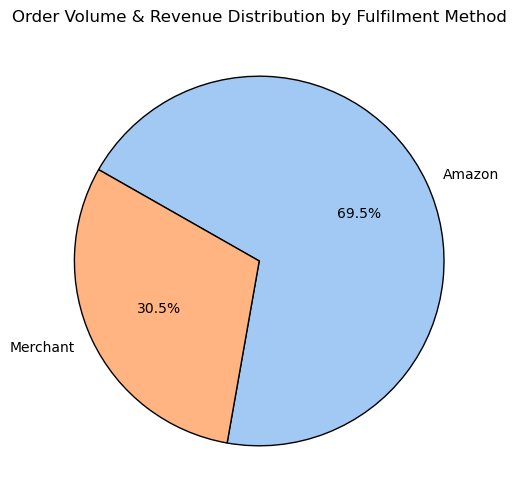

In [113]:
# Define labels and sizes
labels = df_fulfilment_stats.index
sizes = df_fulfilment_stats['% of Orders']  # Order volume percentage
sales_sizes = df_fulfilment_stats['% of Tot. Sales']  # Sales percentage

# Set figure size
plt.figure(figsize=(6, 6))

# Create the pie chart
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=260,
        colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})

# Title
plt.title("Order Volume & Revenue Distribution by Fulfilment Method")

# Show the chart
plt.show()

## Inference: The analysis revealed that 69.5% of the orders were fulfilled by Amazon, while 30.5% were fulfilled by the Merchant.

# 7) Which fulfilment type (Amazon or Merchant) has the highest number of shipped, cancelled, and unshipped orders?

In [37]:
df_shipment_stats = df.query("Courier_Status != 'Unknown'").groupby(['Courier_Status','Fulfilment'])[['Amount','Qty']].sum()\
                                    .sort_values('Amount', ascending=False)\
                                    .reset_index()
df_shipment_stats

,Courier_Status,Fulfilment,Amount,Qty
0,Shipped,Amazon,50329299.0,77858
1,Shipped,Merchant,20726730.0,32035
2,Unshipped,Amazon,3990217.0,6226
3,Unshipped,Merchant,353625.0,527
4,Cancelled,Amazon,0.0,0


In [38]:
df_shipment_stats['Nr. of Orders'] = df.groupby(['Courier_Status','Fulfilment'])[['Order_ID']].count()\
                                    .sort_values('Order_ID', ascending=False)\
                                    .reset_index()['Order_ID']

df_shipment_stats

,Courier_Status,Fulfilment,Amount,Qty,Nr. of Orders
0,Shipped,Amazon,50329299.0,77858,77603
1,Shipped,Merchant,20726730.0,32035,31881
2,Unshipped,Amazon,3990217.0,6226,6872
3,Unshipped,Merchant,353625.0,527,6157
4,Cancelled,Amazon,0.0,0,5932


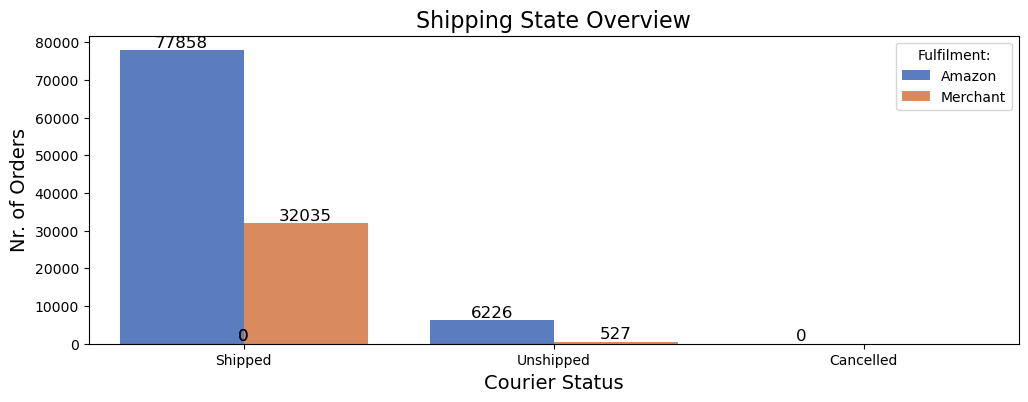

In [117]:
plt.figure(figsize=(12, 4))  # Adjust size
ax = sns.barplot(
    data=df_shipment_stats,
    x='Courier_Status',
    y='Qty',
    hue='Fulfilment',
    palette='muted'
)

# Adding text labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

# Titles and labels
plt.title('Shipping State Overview', fontsize=16)
plt.xlabel('Courier Status', fontsize=14)
plt.ylabel('Nr. of Orders', fontsize=14)
plt.legend(title='Fulfilment:', loc='upper right')  # Legend in upper right

plt.show()


##Inference: Amazon delivers way more orders than merchants. But, Amazon also has more canceled (5,932) and unshipped (6,157) orders, while merchants have only 524 unshipped. This means Amazon handles most shipments but also has more pending orders.

# 8)  How does the fulfillment of Amazon and Merchant vary across the top 20 cities?

In [42]:
df_q7 = df.groupby(['ship_city', 'Fulfilment'])[['Amount','Qty']].sum()\
                                    .sort_values('Amount', ascending=False)\
                                    .reset_index()
df_q7


,ship_city,Fulfilment,Amount,Qty
0,BANGALORE,Amazon,6018305.0,9353
1,HYDERABAD,Amazon,4010209.0,6144
2,MUMBAI,Amazon,3068319.0,4825
3,NEW DELHI,Amazon,2931286.0,4421
4,CHENNAI,Amazon,2596280.0,4319
...,...,...,...,...
9848,BURARI,Amazon,0.0,0
9849,MUSUNURU,Amazon,0.0,0
9850,SERAIKELA KHARSAWAN,Amazon,0.0,0
9851,HARINGHATA,Amazon,0.0,1


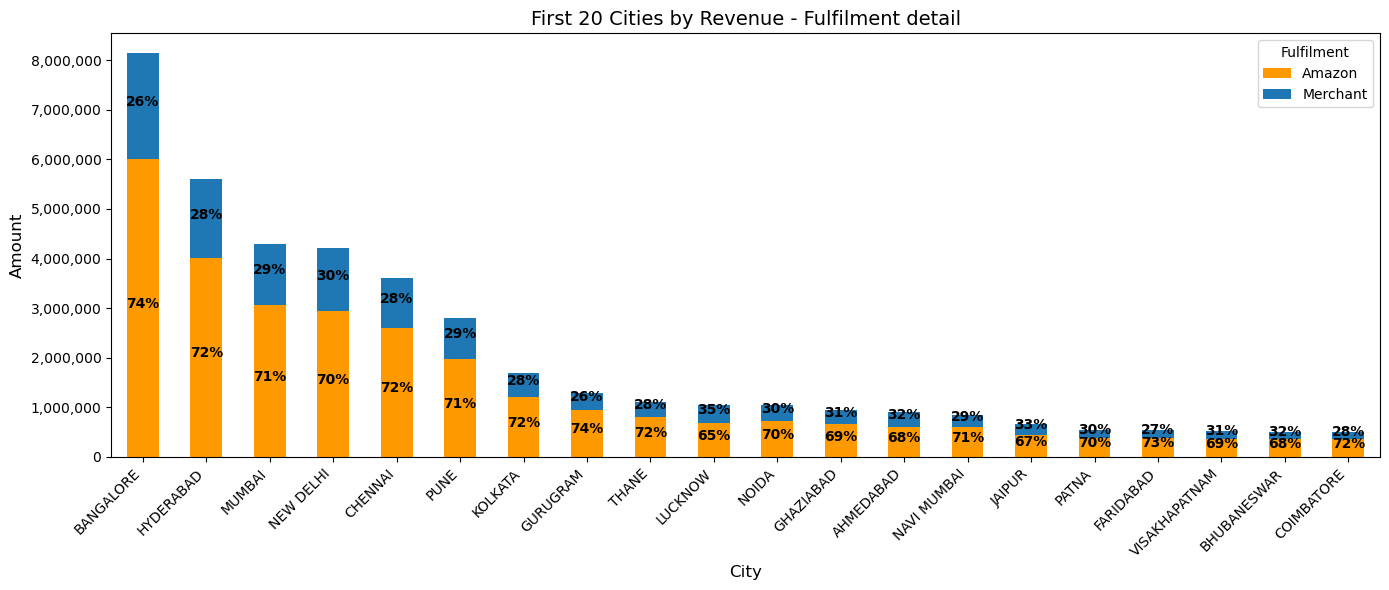

In [125]:
# Take the top 20 cities by revenue
top_cities = df_q7.groupby('ship_city')['Amount'].sum().nlargest(20).index
df_top = df_q7[df_q7['ship_city'].isin(top_cities)]

# Pivot data for stacking
df_pivot = df_top.pivot(index='ship_city', columns='Fulfilment', values='Amount')

# Sorting the data by total revenue
df_pivot = df_pivot.loc[df_pivot.sum(axis=1).sort_values(ascending=False).index]

# Colors to match image
colors = {'Amazon': '#ff9900', 'Merchant': '#1f77b4'}

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
df_pivot.plot(kind='bar', stacked=True, ax=ax, color=[colors[col] for col in df_pivot.columns])

# Remove grid lines
ax.grid(False)

# Add percentage labels inside bars
for i, city in enumerate(df_pivot.index):
    total = df_pivot.loc[city].sum()
    bottom = 0  # To track the bottom position of each stacked bar
    for fulfilment in df_pivot.columns:
        value = df_pivot.loc[city, fulfilment]
        if value > 0:
            percentage = f"{value / total:.0%}"
            ax.text(i, bottom + value / 2, percentage, ha='center', fontsize=10, color='black', fontweight='bold')
            bottom += value

# Labels and title
ax.set_title("First 20 Cities by Revenue - Fulfilment detail", fontsize=14)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Amount", fontsize=12)

# Formatting y-axis with commas
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Rotate x labels
plt.xticks(rotation=45, ha='right')

# Legend placement in the upper right
plt.legend(title="Fulfilment", loc="upper right")

# Tight layout
plt.tight_layout()
plt.show()


## Inference: The Fulfilment ratio between Amazon and Merchant is evenly distributed (around 70%-30%) even when we consider the individual destination cities.

# The following insights were established:

* Western Dress, Kurta, and Set emerged as the top-selling categories.
* The 20 best-selling products by quantity all belong to these three categories.
* However, the 20 best-selling products by revenue are exclusively from the Western Dress and Set categories.
* Additionally, a fulfillment and shipping state overview was conducted, revealing that the fulfillment methods are evenly distributed across destination cities.